## IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Loading Data ...
df = pd.read_csv("train_data.csv",low_memory=False)

In [3]:
# Reviewing
print(df.info())
print("=======================================")
print(df["vote"].value_counts().head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB
None
vote
2.0     43212
2       24835
3.0     21420
3       14083
4.0     12029
4        8726
5.0      7547
5        6070
6.0      5138
6        4385
7.0      3688
7        3270
8.0      2771
8        2576
9.0      2133
9        1995
10       1

In [4]:
# To Int
df["vote"] = pd.to_numeric(df["vote"], errors="coerce").fillna(0).astype(int)

In [5]:
# Check Again
df.info()
df.dropna(subset=["reviewerName"], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            838944 non-null  int64 
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(3), object(7)
memory usage: 64.8+ MB


## CALCULATING TOP 10

In [6]:
# Reviewing Names
df["reviewerName"].value_counts()
df = df[~df["reviewerName"].isin(["Amazon Customer", "Kindle Customer"])]

In [7]:
top = (
    df.groupby("reviewerName")["vote"]
      .sum()
      .sort_values(ascending=False))
print(top.head(10))

reviewerName
Benson Leung    4572
Michael         3710
Mike            3000
John            2730
Dave            2230
David           2194
Chris           2060
Steve           2046
Brian           1988
Matt            1915
Name: vote, dtype: int64


## CONCLUSION



### The top 10 reviewers with the highest total helpful votes are Benson Leung, Michael, Mike, John, Dave, David, Chris, Steve, Brian, and Matt.

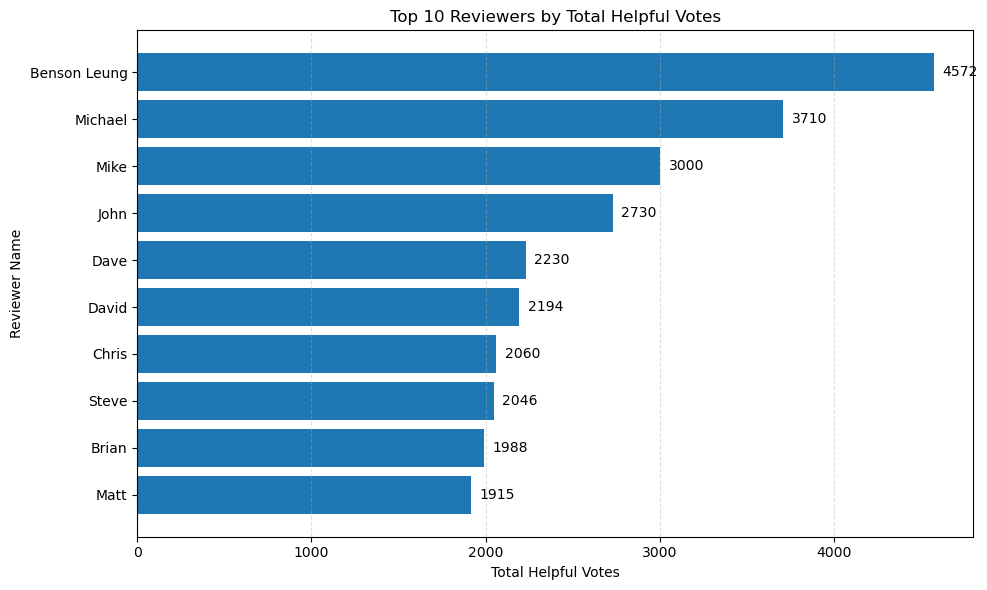

In [23]:
top10 = top.head(10).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
bars = plt.barh(top10.index, top10.values)
plt.xlabel("Total Helpful Votes")
plt.ylabel("Reviewer Name")
plt.title("Top 10 Reviewers by Total Helpful Votes")
plt.grid(axis="x", linestyle="--", alpha=0.4)
for bar in bars:
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center")
plt.tight_layout()
plt.savefig("top_10_reviewers.png", dpi=300, bbox_inches="tight")
plt.show()